##### SENTINEL — TuSimple Lane Detection Dataset Loader\n\n**Notebook 01** — Loads the TuSimple labeled subset, converts raw lane annotations\ninto polynomial labels (`x = ay² + by + c`), resizes images to 320×180, and\nproduces train/val/test splits for notebooks 02–06.\n\n- **Source:** TuSimple (3 626 labeled frames, 1280×720)\n- **Output:** `processed/images/` (320×180 PNGs) + `processed/labels_{train,val,test}.json`\n- **Polynomial convention:** `x = a*y² + b*y + c`, y from top of image\n- **Split:** 70 / 15 / 15, seed=42

---\n## Cell 1 — Imports and config

In [1]:
import json
import random
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Resolution ────────────────────────────────────────────────
IMG_W, IMG_H = 320, 180          # 1280×720 ÷ 4, preserves 16:9

# ── Steering ──────────────────────────────────────────────────
LOOKAHEAD_PX = 45                # rows from bottom for steering error

# ── Polynomial fitting ────────────────────────────────────────
MIN_POLY_PTS = 5                 # min valid points to fit a lane poly

# ── Reproducibility & split ───────────────────────────────────
SEED = 42
SPLIT = (0.70, 0.15, 0.15)      # train / val / test

# ── Paths ─────────────────────────────────────────────────────
TUSIMPLE_ROOT = Path("datasets/tusimple")
FRAME_DIR     = TUSIMPLE_ROOT / "tusimple_preprocessed" / "training" / "frames"
PROCESSED_DIR = Path("processed")
LABEL_FILES   = [
    "label_data_0313.json",
    "label_data_0531.json",
    "label_data_0601.json",
]

# ── Scale factors (1280×720 → 320×180) ───────────────────────
SCALE_X = IMG_W / 1280           # 0.25
SCALE_Y = IMG_H / 720            # 0.25

# ── Create output dirs ───────────────────────────────────────
(PROCESSED_DIR / "images").mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)

print(f"Source:     {TUSIMPLE_ROOT}")
print(f"Frames:     {FRAME_DIR}")
print(f"Output:     {PROCESSED_DIR}")
print(f"Resolution: {IMG_W}x{IMG_H} (scale {SCALE_X}x / {SCALE_Y}y)")
print(f"Labels:     {LABEL_FILES}")

Source:     datasets\tusimple
Frames:     datasets\tusimple\tusimple_preprocessed\training\frames
Output:     processed
Resolution: 320x180 (scale 0.25x / 0.25y)
Labels:     ['label_data_0313.json', 'label_data_0531.json', 'label_data_0601.json']



**Polynomial:** `x = a*y² + b*y + c` — fitted with `np.polyfit(ys, xs, 2)` (y first, x second).  
`y` is measured from the **top** of the image (`0 = top`, `179 = bottom` at `320×180`).

**Steering error:** evaluated at `y_lookahead = IMG_H - LOOKAHEAD_PX = 135`.  
`steering_error = x_mid(y_lookahead) - IMG_W/2`. Positive means the midline is right of centre.

**Ego lane selection:** pick the 2 lanes closest to image centre (`x = 160`) at the bottom-most valid row. Require `>= 5` valid (non-`-2`) points per lane.

#### Cell 3 — Core utilities

In [2]:
def poly_x(coeffs, y):
    """Evaluate x = a*y^2 + b*y + c."""
    a, b, c = coeffs
    return a * y**2 + b * y + c


def fit_poly(pts):
    """Fit degree-2 polynomial to [(x, y), ...]. Returns [a, b, c].

    Convention: np.polyfit(ys, xs, 2) so that x = f(y).
    """
    ys = np.array([p[1] for p in pts], dtype=np.float64)
    xs = np.array([p[0] for p in pts], dtype=np.float64)
    coeffs = np.polyfit(ys, xs, 2)
    return coeffs.tolist()


def avg_poly(left, right):
    """Coefficient-wise average of two polynomials."""
    return [(l + r) / 2.0 for l, r in zip(left, right)]


def steering_error(mid_poly):
    """Lateral error at the lookahead row.

    Positive = midline is right of image centre (steer left to correct).
    """
    y_la = IMG_H - LOOKAHEAD_PX
    x_mid = poly_x(mid_poly, y_la)
    return float(x_mid - IMG_W / 2.0)


def select_ego_lanes(lanes, h_samples):
    """Pick the two ego lanes (left & right of car) from TuSimple annotation.

    Strategy:
      1. For each lane, collect valid (non -2) points, scaled to 320x180.
      2. Discard lanes with < MIN_POLY_PTS valid points.
      3. Among remaining lanes, find the bottom-most y that has at least 2
         lanes with a valid point.
      4. At that y, pick the two lanes whose x-coordinates are closest to
         the image centre (IMG_W / 2).  The one left of centre is left_lane,
         the one right of centre is right_lane.  If both are on the same
         side, take the two closest overall.

    Returns (left_pts, right_pts) as lists of [x, y], or None if < 2 valid.
    """
    cx = IMG_W / 2.0

    # Build scaled point lists per lane, and record bottom-row x
    lane_data = []  # [(pts_list, x_at_bottom)]
    for lane_xs in lanes:
        pts = []
        for x_orig, y_orig in zip(lane_xs, h_samples):
            if x_orig == -2:
                continue
            pts.append([x_orig * SCALE_X, y_orig * SCALE_Y])
        if len(pts) < MIN_POLY_PTS:
            continue
        # x at the bottom-most valid point (last in list since h_samples ascending)
        x_bottom = pts[-1][0]
        lane_data.append((pts, x_bottom))

    if len(lane_data) < 2:
        return None

    # Sort by distance to image centre at bottom row
    lane_data.sort(key=lambda ld: abs(ld[1] - cx))

    # Take the two closest to centre
    pair = lane_data[:2]

    # Assign left / right by x at bottom
    if pair[0][1] <= pair[1][1]:
        left_pts, right_pts = pair[0][0], pair[1][0]
    else:
        left_pts, right_pts = pair[1][0], pair[0][0]

    return left_pts, right_pts


print("Core utilities defined")

Core utilities defined


---\n## Cell 4 — TuSimple loader\n\nReads all 3 JSON label files, maps each `raw_file` to the preprocessed frame in\n`tusimple_preprocessed/training/frames/`, resizes to 320×180, fits polynomials,\nand writes everything to `processed/`.

In [3]:
def raw_file_to_frame_path(raw_file):
    """Map TuSimple raw_file to our preprocessed frame path.

    'clips/0313-1/6040/20.jpg' -> FRAME_DIR / '0313-1_6040.jpg'
    """
    parts = raw_file.replace("clips/", "").split("/")
    clip_id = parts[0]       # e.g. '0313-1'
    frame_id = parts[1]      # e.g. '6040'
    return FRAME_DIR / f"{clip_id}_{frame_id}.jpg"


def make_output_name(raw_file):
    """Derive output image name from raw_file.

    'clips/0313-1/6040/20.jpg' -> '0313-1_6040.png'
    """
    parts = raw_file.replace("clips/", "").split("/")
    return f"{parts[0]}_{parts[1]}.png"


# ── Main loader loop ──────────────────────────────────────────
all_labels = []
skipped = 0

for label_file in LABEL_FILES:
    path = TUSIMPLE_ROOT / label_file
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in tqdm(lines, desc=label_file):
        entry = json.loads(line)
        raw_file = entry["raw_file"]
        lanes = entry["lanes"]
        h_samples = entry["h_samples"]

        # ── Load and resize image ─────────────────────────────
        src_path = raw_file_to_frame_path(raw_file)
        img = cv2.imread(str(src_path))
        if img is None:
            skipped += 1
            continue
        img_small = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)

        # ── Save resized image ────────────────────────────────
        out_name = make_output_name(raw_file)
        out_path = PROCESSED_DIR / "images" / out_name
        cv2.imwrite(str(out_path), img_small)

        # ── Select ego lanes ──────────────────────────────────
        result = select_ego_lanes(lanes, h_samples)

        if result is None:
            # No valid ego lane pair
            label = {
                "image": f"processed/images/{out_name}",
                "has_lane": False,
                "left_poly": None,
                "right_poly": None,
                "mid_poly": None,
                "steering_error": None,
                "left_pts": [],
                "right_pts": [],
                "mid_pts": [],
                "lane_width_px": None,
                "source": "tusimple",
            }
        else:
            left_pts, right_pts = result

            # ── Fit polynomials ───────────────────────────────
            left_poly = fit_poly(left_pts)
            right_poly = fit_poly(right_pts)
            mid_poly = avg_poly(left_poly, right_poly)
            err = steering_error(mid_poly)

            # ── Sample midline points for storage ─────────────
            ys_mid = sorted(set(
                [p[1] for p in left_pts] + [p[1] for p in right_pts]
            ))
            mid_pts = [[float(poly_x(mid_poly, y)), float(y)] for y in ys_mid]

            # ── Lane width at bottom of image ─────────────────
            y_bottom = float(IMG_H - 1)
            x_left_bot = poly_x(left_poly, y_bottom)
            x_right_bot = poly_x(right_poly, y_bottom)
            lane_width = abs(x_right_bot - x_left_bot)

            label = {
                "image": f"processed/images/{out_name}",
                "has_lane": True,
                "left_poly": left_poly,
                "right_poly": right_poly,
                "mid_poly": mid_poly,
                "steering_error": err,
                "left_pts": [[float(x), float(y)] for x, y in left_pts],
                "right_pts": [[float(x), float(y)] for x, y in right_pts],
                "mid_pts": mid_pts,
                "lane_width_px": float(lane_width),
                "source": "tusimple",
            }

        all_labels.append(label)

# ── Summary ───────────────────────────────────────────────────
n_lane = sum(1 for l in all_labels if l["has_lane"])
n_nolane = sum(1 for l in all_labels if not l["has_lane"])
print(f"\nProcessed: {len(all_labels)} images")
print(f"  has_lane=True:  {n_lane}")
print(f"  has_lane=False: {n_nolane}")
print(f"  skipped (missing img): {skipped}")

label_data_0601.json: 100%|██████████| 410/410 [00:11<00:00, 34.68it/s]


Processed: 3626 images
  has_lane=True:  3626
  has_lane=False: 0
  skipped (missing img): 0


---\n## Cell 5 — QA visualisation\n\n12 random samples with left (red), right (blue), midline (green) overlaid.

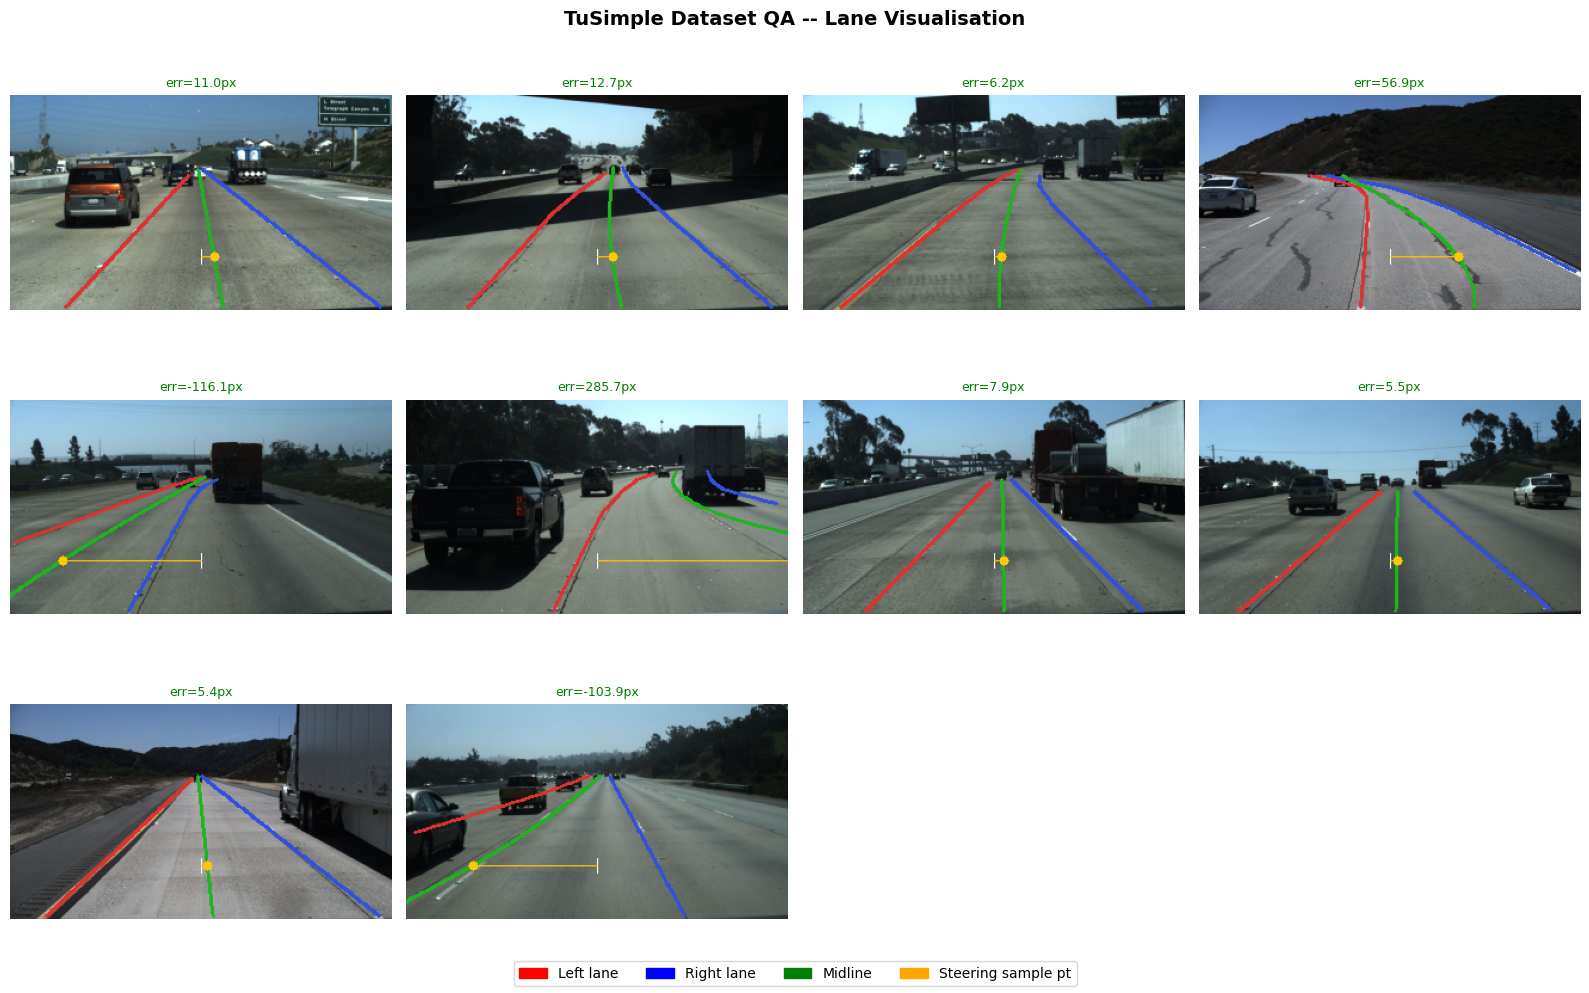

Saved: processed\qa_samples.png


In [4]:
lane_labels = [l for l in all_labels if l["has_lane"]]
nolane_labels = [l for l in all_labels if not l["has_lane"]]

# Pick 10 lane + 2 no-lane (or fewer if not enough no-lane)
rng = random.Random(SEED)
n_lane_show = min(10, len(lane_labels))
n_nolane_show = min(2, len(nolane_labels))
samples = rng.sample(lane_labels, n_lane_show) + rng.sample(nolane_labels, n_nolane_show)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("TuSimple Dataset QA -- Lane Visualisation", fontsize=14, fontweight="bold")

for ax, label in zip(axes.flat, samples):
    img = cv2.imread(label["image"])
    if img is None:
        ax.set_title("IMAGE NOT FOUND", color="red", fontsize=9)
        ax.axis("off")
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()

    if label["has_lane"]:
        # Draw left (red), right (blue), midline (green)
        for pts, color in [
            (label["left_pts"],  (220, 50, 50)),
            (label["right_pts"], (50, 80, 220)),
            (label["mid_pts"],   (30, 180, 30)),
        ]:
            for j in range(len(pts) - 1):
                x1, y1 = int(pts[j][0]), int(pts[j][1])
                x2, y2 = int(pts[j + 1][0]), int(pts[j + 1][1])
                cv2.line(overlay, (x1, y1), (x2, y2), color, 2)

        # Steering error indicator
        y_la = IMG_H - LOOKAHEAD_PX
        x_mid = int(round(poly_x(label["mid_poly"], y_la)))
        x_ctr = IMG_W // 2
        cv2.circle(overlay, (x_mid, y_la), 4, (255, 200, 0), -1)
        cv2.line(overlay, (x_ctr, y_la - 6), (x_ctr, y_la + 6), (255, 255, 255), 1)
        cv2.line(overlay, (x_mid, y_la), (x_ctr, y_la), (255, 200, 0), 1)

        err = label["steering_error"]
        ax.set_title(f"err={err:.1f}px", fontsize=9, color="green")
    else:
        ax.set_title("no lane", fontsize=9, color="red")

    ax.imshow(overlay)
    ax.axis("off")

# Hide any unused subplots
for ax in axes.flat[len(samples):]:
    ax.axis("off")

patches = [
    mpatches.Patch(color="red",    label="Left lane"),
    mpatches.Patch(color="blue",   label="Right lane"),
    mpatches.Patch(color="green",  label="Midline"),
    mpatches.Patch(color="orange", label="Steering sample pt"),
]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=10)
plt.tight_layout()
qa_path = PROCESSED_DIR / "qa_samples.png"
plt.savefig(str(qa_path), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {qa_path}")

---\n## Cell 6 — Dataset statistics

Total images:     3626
  has_lane=True:  3626
  has_lane=False: 0
  ratio:          100.0% lane / 0.0% no-lane


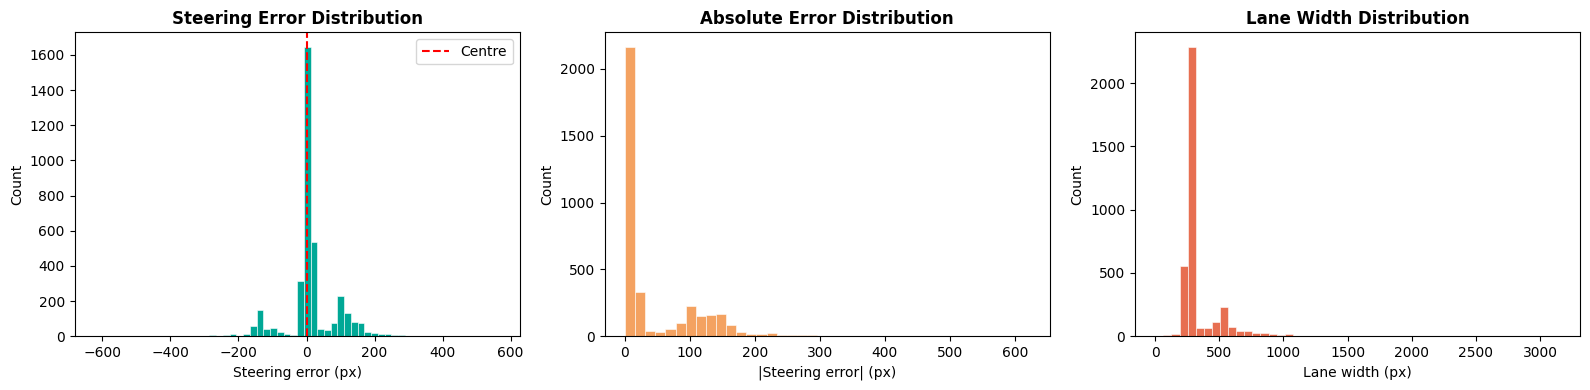


Steering error:  mean=13.60  std=77.52  min=-622.60  max=566.80
Lane width:      mean=332.5  std=193.0  min=1.5  max=3153.5
Saved: processed\dataset_statistics.png


In [5]:
print(f"Total images:     {len(all_labels)}")
print(f"  has_lane=True:  {n_lane}")
print(f"  has_lane=False: {n_nolane}")
print(f"  ratio:          {n_lane/len(all_labels)*100:.1f}% lane / {n_nolane/len(all_labels)*100:.1f}% no-lane")

# ── Steering error distribution ────────────���──────────────────
errors = np.array([l["steering_error"] for l in all_labels if l["steering_error"] is not None])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(errors, bins=60, color="#00A896", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Centre")
axes[0].set_xlabel("Steering error (px)")
axes[0].set_ylabel("Count")
axes[0].set_title("Steering Error Distribution", fontweight="bold")
axes[0].legend()

axes[1].hist(np.abs(errors), bins=40, color="#F4A261", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("|Steering error| (px)")
axes[1].set_ylabel("Count")
axes[1].set_title("Absolute Error Distribution", fontweight="bold")

# ── Lane width distribution ─────────────��─────────────────────
widths = np.array([l["lane_width_px"] for l in all_labels if l["lane_width_px"] is not None])

axes[2].hist(widths, bins=50, color="#E76F51", edgecolor="white", linewidth=0.4)
axes[2].set_xlabel("Lane width (px)")
axes[2].set_ylabel("Count")
axes[2].set_title("Lane Width Distribution", fontweight="bold")

plt.tight_layout()
stats_path = PROCESSED_DIR / "dataset_statistics.png"
plt.savefig(str(stats_path), dpi=120, bbox_inches="tight")
plt.show()

print(f"\nSteering error:  mean={errors.mean():.2f}  std={errors.std():.2f}  "
      f"min={errors.min():.2f}  max={errors.max():.2f}")
print(f"Lane width:      mean={widths.mean():.1f}  std={widths.std():.1f}  "
      f"min={widths.min():.1f}  max={widths.max():.1f}")
print(f"Saved: {stats_path}")

---\n## Cell 7 — Train / Val / Test split (70 / 15 / 15)

In [6]:
random.seed(SEED)
labels_copy = list(all_labels)
random.shuffle(labels_copy)

n_total = len(labels_copy)
n_train = int(n_total * SPLIT[0])
n_val   = int(n_total * SPLIT[1])
n_test  = n_total - n_train - n_val

splits = {
    "train": labels_copy[:n_train],
    "val":   labels_copy[n_train:n_train + n_val],
    "test":  labels_copy[n_train + n_val:],
}

for split_name, split_data in splits.items():
    out_path = PROCESSED_DIR / f"labels_{split_name}.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(split_data, f, indent=2)

    has = sum(1 for l in split_data if l["has_lane"])
    no  = len(split_data) - has
    print(f"{split_name:5s}: {len(split_data):5d} images  "
          f"({has} lane, {no} no-lane)")

print(f"\nSplit files written to {PROCESSED_DIR}/:")
print(f"  labels_train.json  ({n_train} samples)")
print(f"  labels_val.json    ({n_val} samples)")
print(f"  labels_test.json   ({n_test} samples)")
print(f"\nNext: 02_classical_pipeline.ipynb")

train:  2538 images  (2538 lane, 0 no-lane)
val  :   543 images  (543 lane, 0 no-lane)
test :   545 images  (545 lane, 0 no-lane)

Split files written to processed/:
  labels_train.json  (2538 samples)
  labels_val.json    (543 samples)
  labels_test.json   (545 samples)

Next: 02_classical_pipeline.ipynb
